# 01 — Data Exploration

First-pass inspection of the **State Disability Policy Index (SDPI)** dataset. 36 policy indicators across 5 domains, 51 jurisdictions, 2023–2024. No transformations yet — this notebook is purely exploratory.

In [1]:
import pandas as pd
import numpy as np
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Load the raw data

In [2]:
df = pd.read_csv("../data/SDPI_final_all_methods.csv")
df.shape

(51, 40)

In [3]:
print('Columns:', df.columns.tolist())

Columns: ['State', 'avg_monthly_ssi_payment', 'caps', 'arp_caregiver_family_support', 'ui_good_cause_caregiving', 'spousal_impoverishment', 'hcbs_expenditure_ratio', 'hcbs_user_ratio', 'pct_ltss_hcbs_older_adults', 'home_health_aides_per100', 'arp_waiting_list_diversion', 'arp_tech_telehealth', 'arp_cross_sector_investments', 'livability_transportation', 'livability_housing', 'hcbs_presumptive_eligibility', 'section_811_pra', 'vr_spending_career', 'vr_spending_training', 'special_ed_policy_score', 'arp_workforce_training', 'buy_in_working_people', 'subminimum_wage_14c', 'medicaid_eligibility_threshold', 'ssi_auto_enroll_medicaid', 'medically_needy', 'ssi_criteria_209', 'arp_quality_improvement', 'smd_demonstration_projects', 'initial_ar', 'reconsidered_ar', 'total_ar', 'adl_medicaid_coverage_pct', 'private_ltci_per1000', 'section_811_pct_disability', 'fema_shmp', 'family_responsibility_class', 'sdpi_minmax', 'sdpi_zscore', 'sdpi_hybrid']


## Summary statistics — three composite SDPI scores

In [4]:
score_cols = ['sdpi_minmax','sdpi_zscore','sdpi_hybrid']
df[score_cols].describe().round(3)

,sdpi_minmax,sdpi_zscore,sdpi_hybrid
count,51.000,51.000,51.000
mean,0.416,0.000,0.322
std,0.106,0.286,0.204
min,0.209,-0.542,-0.036
25%,0.333,-0.201,0.169
50%,0.414,-0.043,0.287
75%,0.471,0.183,0.487
max,0.657,0.727,0.838


## Cross-method correlations

If all three methods agree (r ≥ 0.85), rankings are robust to normalization choice.

In [5]:
df[score_cols].corr().round(3)

,sdpi_minmax,sdpi_zscore,sdpi_hybrid
sdpi_minmax,1.000,0.934,0.873
sdpi_zscore,0.934,1.000,0.970
sdpi_hybrid,0.873,0.970,1.000


## Top 5 and bottom 5 states — hybrid SDPI

In [6]:
print('TOP 5:')
df.nlargest(5,'sdpi_hybrid')[['State','sdpi_hybrid']]


TOP 5:


,State,sdpi_hybrid
47,Washington,0.838153
38,Pennsylvania,0.657671
32,New York,0.633745
4,California,0.617500
8,District of Columbia,0.609529


In [7]:
print('BOTTOM 5:')
df.nsmallest(5,'sdpi_hybrid')[['State','sdpi_hybrid']]


BOTTOM 5:


,State,sdpi_hybrid
42,Tennessee,-0.035585
0,Alabama,-0.002604
17,Kentucky,0.019959
40,South Carolina,0.031925
36,Oklahoma,0.063474


## Distribution of hybrid SDPI scores

(array([3., 2., 6., 5., 6., 5., 6., 3., 2., 3., 4., 5., 0., 0., 1.]),
 array([-0.03558488,  0.02266434,  0.08091356,  0.13916278,  0.19741199,
         0.25566121,  0.31391043,  0.37215965,  0.43040887,  0.48865809,
         0.5469073 ,  0.60515652,  0.66340574,  0.72165496,  0.77990418,
         0.8381534 ]),
 <BarContainer object of 15 artists>)

[Text(0.5, 0, 'Hybrid SDPI'),
 Text(0, 0.5, 'States'),
 Text(0.5, 1.0, 'Distribution of Hybrid SDPI Scores')]

<Axes: xlabel='sdpi_hybrid'>

[Text(0.5, 0, 'Hybrid SDPI'), Text(0.5, 1.0, 'Boxplot')]

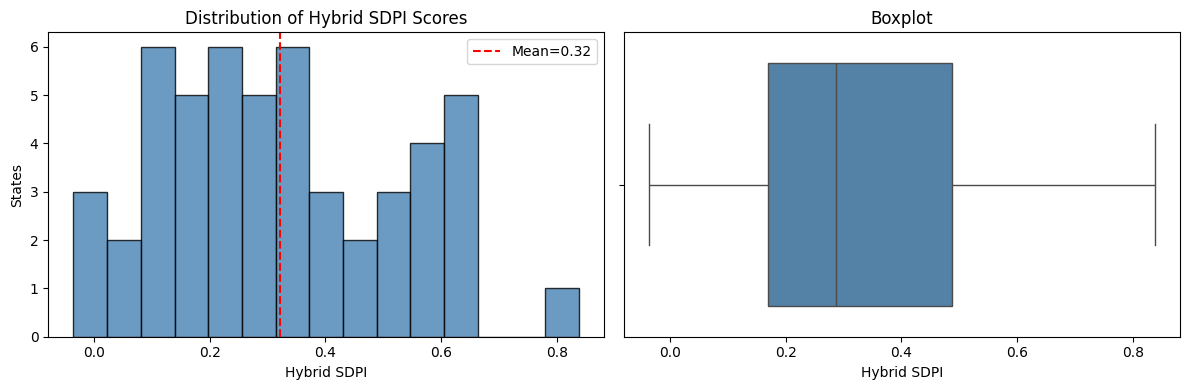

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].hist(df['sdpi_hybrid'],bins=15,color='steelblue',edgecolor='black',alpha=0.8)
axes[0].axvline(df['sdpi_hybrid'].mean(),color='red',linestyle='--',label=f"Mean={df['sdpi_hybrid'].mean():.2f}")
axes[0].set(xlabel='Hybrid SDPI',ylabel='States',title='Distribution of Hybrid SDPI Scores')
axes[0].legend()
sns.boxplot(data=df,x='sdpi_hybrid',ax=axes[1],color='steelblue')
axes[1].set(xlabel='Hybrid SDPI',title='Boxplot')
plt.tight_layout(); plt.show()

## Key observation

The three normalization methods are highly correlated, confirming ranking robustness. The hybrid method is the primary specification: it z-scores continuous indicators while retaining binary and ordinal indicators on their original scales.